# **Topic Modelling**

### USING LDA

In [ ]:
# 1. (Opsional) Install dulu library yang diperlukan:
#    pip install pandas scikit-learn langdetect

import pandas as pd
from langdetect import detect
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

# Asumsi: File CSV bernama 'preprocessed_data.csv' berada di direktori yang sama dengan skrip Python
df = pd.read_csv(r"D:\Internship\AIBeecara\PROJECT TEST\data_stemm_2.csv")

# Menampilkan beberapa baris pertama dari DataFrame untuk verifikasi
print(df.head())

# 3. Deteksi bahasa (menghasilkan 'en', 'id', atau 'unknown')
def detect_lang(text):
    try:
        return detect(text)
    except:
        return 'unknown'

df['lang'] = df['stemmed'].apply(detect_lang)

# 4. Fungsi untuk menjalankan LDA pada subset bahasa tertentu
def run_lda(texts, n_topics=5, max_df=0.9, min_df=5, n_top_words=10):
    """
    texts      : list of str (dokumen yang akan di-LDA)
    n_topics   : jumlah topik
    max_df     : abaikan kata yang muncul di > max_df proporsi dokumen
    min_df     : abaikan kata yang muncul di < min_df dokumen
    """
    # Buat Document-Term Matrix
    vect = CountVectorizer(max_df=max_df, min_df=min_df)
    dtm = vect.fit_transform(texts)
    
    # Fit LDA
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch'
    )
    lda.fit(dtm)
    
    # Tampilkan top words per topic
    feature_names = vect.get_feature_names_out()
    for idx, topic in enumerate(lda.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]]
        print(f"Topic #{idx+1}: {', '.join(top_words)}")

# 5. Jalankan untuk masing-masing bahasa
for lang_code in ['en', 'id']:
    subset = df[df['lang'] == lang_code]['stemmed'].tolist()
    if subset:
        print(f"\n=== Topics for language: {lang_code} ===")
        run_lda(
            texts=subset,
            n_topics=5,       # misalnya 5 topik per bahasa
            max_df=0.8,       # abaikan kata yang terlalu umum
            min_df=5,         # abaikan kata yang terlalu jarang
            n_top_words=10    # 10 kata teratas tiap topik
        )
    else:
        print(f"\n(no documents for language '{lang_code}')")


### USING LDA+BERT

In [23]:
# 1. (jika belum) install dependencies:
#    pip install pandas scikit-learn langdetect textblob transformers torch

import pandas as pd
from langdetect import detect
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob
from transformers import pipeline

# 2. Load data
df = pd.read_csv('data_stemm.csv')

# 3. Deteksi bahasa aman
def detect_lang_safe(text):
    if not isinstance(text, str) or not text.strip():
        return 'unknown'
    try:
        return detect(text)
    except:
        return 'unknown'

df['lang'] = df['stemmed'].apply(detect_lang_safe)

# 4. Filter komentar valid (hanya 'en' & 'id', non-empty)
df = df[df['lang'].isin(['en','id'])].copy()
df = df[df['stemmed'].str.strip() != '']

# 5. Vectorizer + LDA (5 topik)
vect = CountVectorizer(max_df=0.8, min_df=5)
dtm  = vect.fit_transform(df['stemmed'])
lda  = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

# 6. Assign topik dominan
topic_dist = lda.transform(dtm)           # (n_docs, n_topics)
df['dominant_topic'] = topic_dist.argmax(axis=1)

# 7. Siapkan sentiment analyzers
#    – English pakai TextBlob
def sentiment_en(text):
    p = TextBlob(text).sentiment.polarity
    return 'positive' if p>0.1 else 'negative' if p<-0.1 else 'neutral'

#    – Indonesian pakai Roberta-light model
sent_id_pipe = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier"
)
def sentiment_id(text):
    # pipe mengembalikan [{'label': 'POSITIVE'|'NEGATIVE'|'NEUTRAL', 'score':...}]
    out = sent_id_pipe(text[:512])[0]
    lbl = out['label'].lower()
    # sesuaikan:
    if 'neg' in lbl: return 'negative'
    if 'pos' in lbl: return 'positive'
    return 'neutral'

# 8. Terapkan sentiment sesuai bahasa
def get_sent(row):
    return sentiment_en(row['stemmed']) if row['lang']=='en' else sentiment_id(row['stemmed'])

df['sentiment'] = df.apply(get_sent, axis=1)

# 9. Ringkasan: hitung distribusi per (topik, sentiment) + label mayoritas
summary = (
    df
    .groupby(['dominant_topic','sentiment'])
    .size()
    .unstack(fill_value=0)
)
summary['topic_sentiment'] = summary.idxmax(axis=1)

print(summary)


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

sentiment       negative  neutral  positive topic_sentiment
dominant_topic                                             
0                     40      118       136        positive
1                     39       10        18        negative
2                    150       90       662        positive
3                     35      105       284        positive
4                     21       89       170        positive


In [2]:
# 1. Instalasi (jika perlu)
# pip install pandas scikit-learn langdetect textblob transformers torch

import pandas as pd
from langdetect import detect
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob
from transformers import pipeline

# 2. Load & deteksi bahasa (tangani NaN)
df = pd.read_csv('data_stemm.csv')
def detect_lang_safe(text):
    if not isinstance(text, str) or not text.strip(): return 'unknown'
    try: return detect(text)
    except: return 'unknown'
df['lang'] = df['stemmed'].apply(detect_lang_safe)
df = df[df['lang'].isin(['en','id'])].copy()
df = df[df['stemmed'].str.strip() != '']

# 3. Siapkan sentiment analyzers
# English via TextBlob
def sentiment_en(txt):
    p = TextBlob(txt).sentiment.polarity
    return 'positive' if p>0.1 else 'negative' if p<-0.1 else 'neutral'

# Indonesian via Roberta classifier
sent_id = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier"
)
def sentiment_id(txt):
    out = sent_id(txt[:512])[0]
    lbl = out['label'].lower()
    if 'neg' in lbl: return 'negative'
    if 'pos' in lbl: return 'positive'
    return 'neutral'

# 4. Fungsi helper: process per bahasa
def analyze_language(df, lang_code, n_topics=5, n_top_words=10):
    sub = df[df['lang']==lang_code].copy()
    texts = sub['stemmed'].tolist()
    
    # a) Vectorize & fit LDA
    vect = CountVectorizer(max_df=0.8, min_df=5)
    dtm  = vect.fit_transform(texts)
    lda  = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(dtm)
    
    # b) Assign topik dominan
    topic_dist = lda.transform(dtm)
    sub['dominant_topic'] = topic_dist.argmax(axis=1)
    
    # c) Hitung sentiment per dokumen
    if lang_code=='en':
        sub['sentiment'] = sub['stemmed'].apply(sentiment_en)
    else:
        sub['sentiment'] = sub['stemmed'].apply(sentiment_id)
    
    # d) Ringkasan sentiment per topik
    summary = (sub
               .groupby(['dominant_topic','sentiment'])
               .size()
               .unstack(fill_value=0))
    summary['topic_sentiment'] = summary.idxmax(axis=1)
    
    # e) Cetak top words + topic_sentiment
    feat = vect.get_feature_names_out()
    print(f"\n=== Language: {lang_code} ===")
    for t in range(n_topics):
        # top words
        top_idx = lda.components_[t].argsort()[:-n_top_words-1:-1]
        topw    = [feat[i] for i in top_idx]
        sent_lbl= summary.loc[t,'topic_sentiment']
        print(f"Topic {t+1} ({sent_lbl}): {', '.join(topw)}")
    
    # f) Tampilkan tabel summary jika mau
    print("\nDistribution per topic & sentiment:")
    print(summary)
    return sub, summary

# 5. Jalankan untuk 'en' dan 'id'
#sub_en, summary_en = analyze_language(df, 'en', n_topics=5, n_top_words=10)
#sub_id, summary_id = analyze_language(df, 'id', n_topics=5, n_top_words=10)


In [3]:
# 5. Jalankan untuk 'en' dan 'id'
sub_en, summary_en = analyze_language(df, 'en', n_topics=3, n_top_words=30)
sub_id, summary_id = analyze_language(df, 'id', n_topics=3, n_top_words=30)


=== Language: en ===
Topic 1 (positive): app, ad, lesson, use, heart, learn, get, practic, time, im, chang, make, duolingo, streak, pay, updat, one, everi, free, year, day, watch, earn, like, complet, ive, realli, dont, back, cant
Topic 2 (positive): learn, languag, app, word, like, duolingo, use, make, good, new, realli, would, also, lesson, way, help, cours, great, fun, im, time, speak, dont, ive, get, one, grammar, teach, love, exercis
Topic 3 (positive): get, use, duolingo, app, free, pay, learn, subscript, ad, lesson, super, dont, even, time, year, max, xp, paid, version, money, trial, one, want, good, keep, much, make, would, day, im

Distribution per topic & sentiment:
sentiment       negative  neutral  positive topic_sentiment
dominant_topic                                             
0                     42      127       196        positive
1                     40      130       294        positive
2                     13       58       102        positive

=== Language:

### EVALUATION

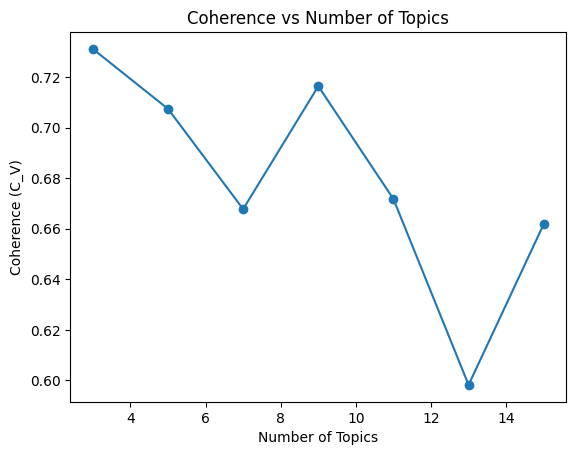

In [2]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# Initialize CountVectorizer
vect = CountVectorizer(max_df=0.8, min_df=5)
# Tokenize the 'stemmed' column into a list of words for each document
docs = [doc.split() for doc in df['stemmed']]

# Create a Gensim dictionary from the tokenized documents
id2word = Dictionary(docs)

coherences = []
topic_nums = list(range(3, 16, 2))
for k in topic_nums:
    lda_k = LatentDirichletAllocation(n_components=k, random_state=42)
    dtm_k = vect.fit_transform(df['stemmed'])
    lda_k.fit(dtm_k)
    # Generate topics list
    topics_k = [[vect.get_feature_names_out()[i] 
                 for i in comp.argsort()[:-11:-1]]
                for comp in lda_k.components_]
    cm_k = CoherenceModel(
        topics=topics_k, texts=docs, dictionary=id2word, coherence='c_v'
    )
    coherences.append(cm_k.get_coherence())

plt.plot(topic_nums, coherences, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence (C_V)")
plt.title("Coherence vs Number of Topics")
plt.show()


In [3]:
coherences

[0.7311735964484649,
 0.7074510319734411,
 0.6677801548820231,
 0.7164266724170498,
 0.6717644905874334,
 0.5982043019703629,
 0.6618525119180094]

### Visualisasi Topik

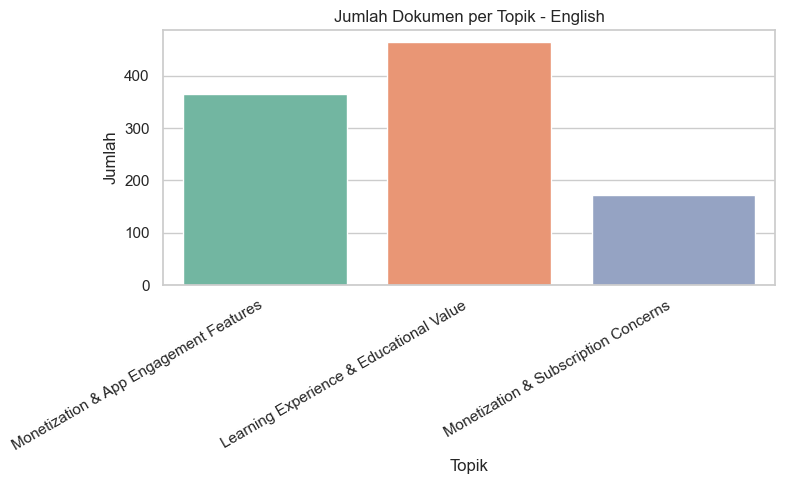

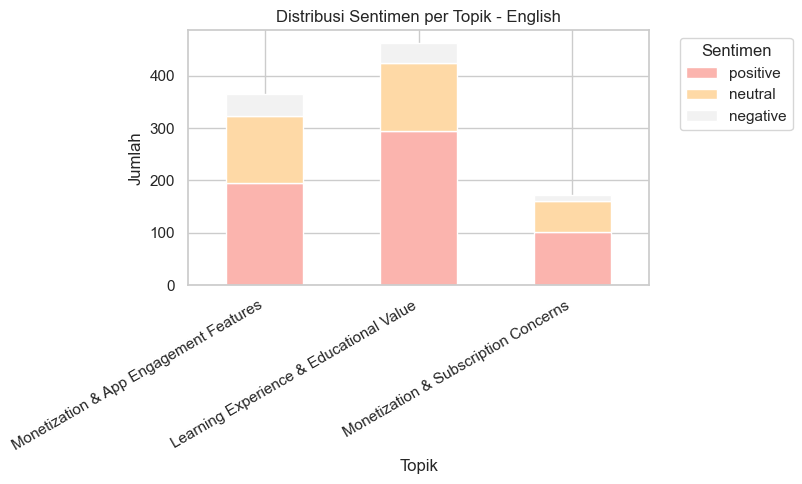

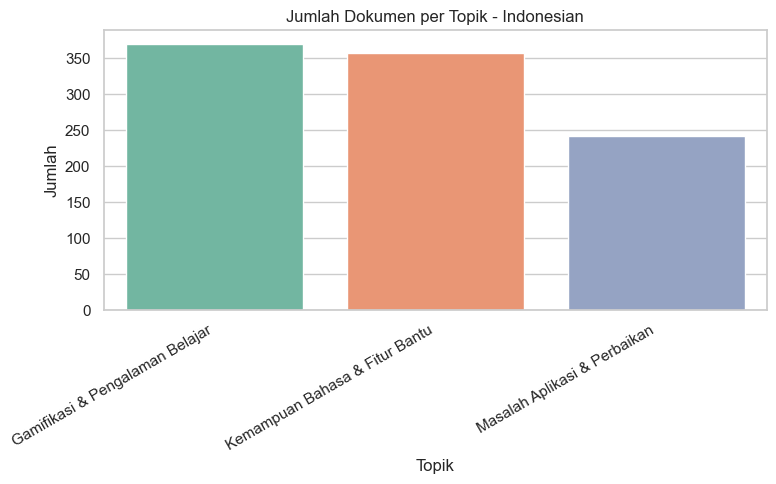

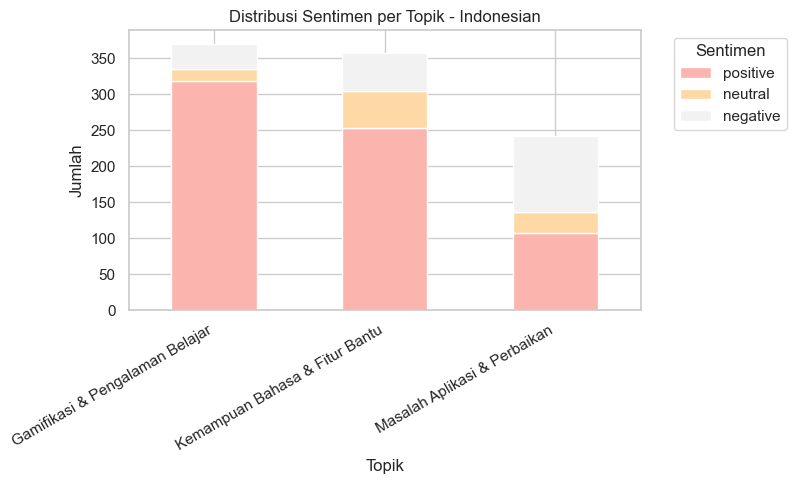

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Atur style visual
sns.set(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

# Mapping nama topik
topic_names_en = {
    0: 'Monetization & App Engagement Features',
    1: 'Learning Experience & Educational Value',
    2: 'Monetization & Subscription Concerns'
}

topic_names_id = {
    0: 'Gamifikasi & Pengalaman Belajar',
    1: 'Kemampuan Bahasa & Fitur Bantu',
    2: 'Masalah Aplikasi & Perbaikan'
}

# Fungsi visualisasi
def visualize_topics(sub_df, summary, lang_label, topic_names):
    # Plot jumlah dokumen per topik
    plt.figure(figsize=(8,5))
    sns.countplot(data=sub_df, x='dominant_topic', palette='Set2')
    plt.title(f'Jumlah Dokumen per Topik - {lang_label}')
    plt.xlabel('Topik')
    plt.ylabel('Jumlah')
    plt.xticks(ticks=range(len(topic_names)), labels=[topic_names[i] for i in range(len(topic_names))], rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Plot distribusi sentimen per topik (stacked bar)
    sent_order = ['positive', 'neutral', 'negative']
    summary = summary.reindex(columns=sent_order, fill_value=0)
    summary[['positive','neutral','negative']].plot(
        kind='bar', stacked=True, figsize=(8,5), colormap='Pastel1')
    plt.title(f'Distribusi Sentimen per Topik - {lang_label}')
    plt.ylabel('Jumlah')
    plt.xlabel('Topik')
    plt.xticks(ticks=range(len(topic_names)), labels=[topic_names[i] for i in range(len(topic_names))], rotation=30, ha='right')
    plt.legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Jalankan untuk English dan Indonesian
visualize_topics(sub_en, summary_en, 'English', topic_names_en)
visualize_topics(sub_id, summary_id, 'Indonesian', topic_names_id)


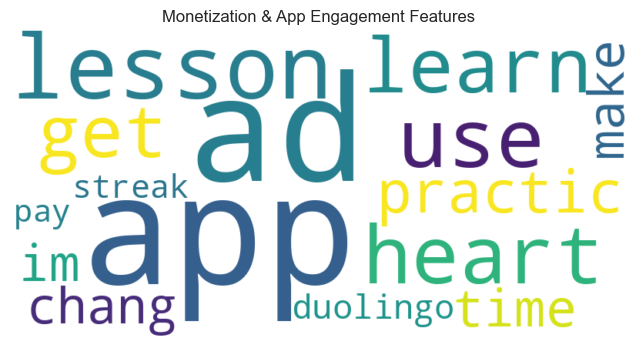

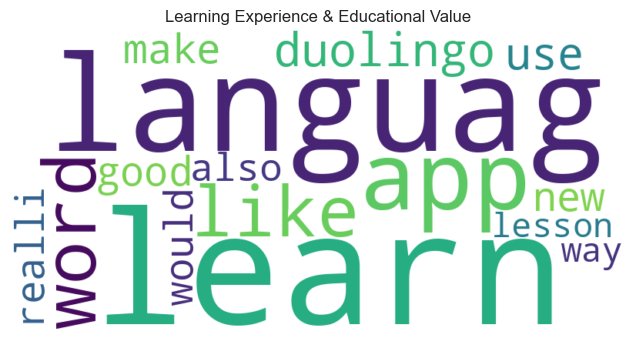

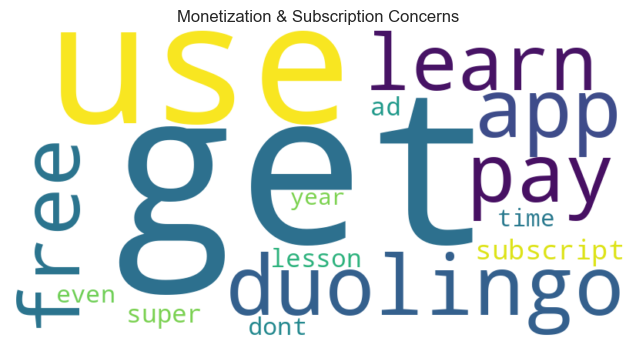

In [9]:
def generate_wordclouds(lda_model, feature_names, n_top_words=15, topic_names=None):
    for t, comp in enumerate(lda_model.components_):
        top_idx = comp.argsort()[:-n_top_words - 1:-1]
        top_words = {feature_names[i]: comp[i] for i in top_idx}
        
        wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_words)
        plt.figure(figsize=(8, 4))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        title = f"Topik {t+1}" if topic_names is None else f"{topic_names[t]}"
        plt.title(title)
        plt.show()

# Contoh penggunaan:
# Use the appropriate lda model (English or Indonesian)
# Ensure vect is initialized
vect = CountVectorizer(max_df=0.8, min_df=5)

generate_wordclouds(lda_model=LatentDirichletAllocation(n_components=3, random_state=42).fit(vect.fit_transform(sub_en['stemmed'])), 
                    feature_names=vect.get_feature_names_out(), 
                    topic_names=topic_names_en)


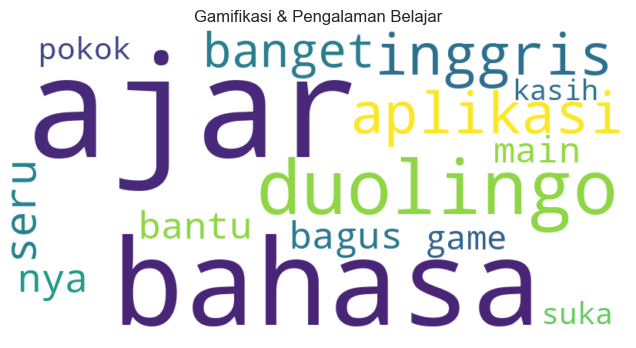

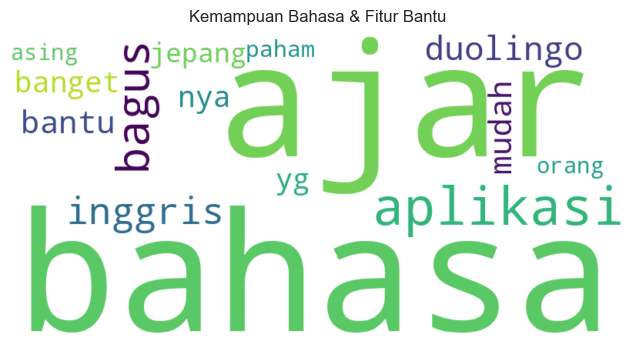

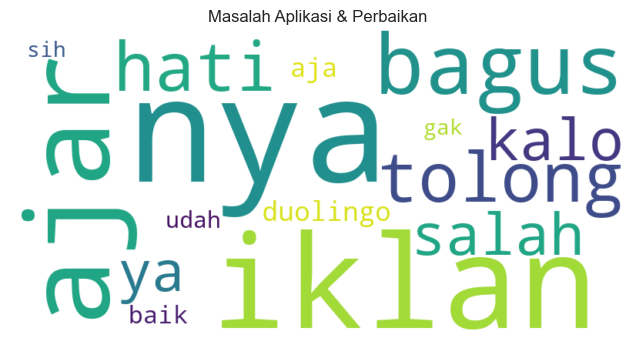

In [10]:
# Generate wordclouds for Indonesian topics
generate_wordclouds(
    lda_model=LatentDirichletAllocation(n_components=3, random_state=42).fit(vect.fit_transform(sub_id['stemmed'])), 
    feature_names=vect.get_feature_names_out(), 
    topic_names=topic_names_id
)

### DASHBOARD

In [17]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import pandas as pd
from wordcloud import WordCloud
import base64
from io import BytesIO

# Contoh dataframe (ganti dengan punyamu)
# sub_en dan summary_en diambil dari hasil LDA
# topic_names_en = {0: 'Monetization', 1: 'Learning Experience', 2: 'Subscription'}

# Membuat dataframe distribusi jumlah dokumen per topik
doc_counts = sub_en['dominant_topic'].value_counts().sort_index()
doc_df = pd.DataFrame({'Topic': list(topic_names_en.values()), 'Count': doc_counts.values})

# Membuat dataframe distribusi sentimen per topik
sentiment_df = summary_en.copy()
sentiment_df['Topic'] = list(topic_names_en.values())

# Membuat WordCloud images sebagai base64
def create_wordcloud_image(topic_index, lda_model, feature_names, n_top_words=20):
    comp = lda_model.components_[topic_index]
    top_idx = comp.argsort()[:-n_top_words - 1:-1]
    top_words = {feature_names[i]: comp[i] for i in top_idx}

    wc = WordCloud(width=600, height=300, background_color='white').generate_from_frequencies(top_words)
    buffer = BytesIO()
    wc.to_image().save(buffer, format='PNG')
    encoded = base64.b64encode(buffer.getvalue()).decode()
    return f'data:image/png;base64,{encoded}'

# Fit LDA model for English subset
vect_en = CountVectorizer(max_df=0.8, min_df=5)
dtm_en = vect_en.fit_transform(sub_en['stemmed'])
lda_en = LatentDirichletAllocation(n_components=len(topic_names_en), random_state=42)
lda_en.fit(dtm_en)

# Pre-generate wordclouds
wordcloud_images = {
    topic_names_en[i]: create_wordcloud_image(i, lda_en, vect_en.get_feature_names_out())
    for i in range(len(topic_names_en))
}

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H2("Duolingo Topic & Sentiment Dashboard (English)"),
    
    dcc.Graph(
        id='doc-counts',
        figure=px.bar(doc_df, x='Topic', y='Count', title='Jumlah Dokumen per Topik')
    ),

    dcc.Graph(
        id='sentiment-dist',
        figure=px.bar(
            sentiment_df.melt(id_vars='Topic', var_name='Sentiment', value_name='Count'),
            x='Topic', y='Count', color='Sentiment',
            barmode='stack', title='Distribusi Sentimen per Topik'
        )
    ),

    html.Div([
        html.Label("Pilih Topik untuk WordCloud:"),
        dcc.Dropdown(
            id='topic-dropdown',
            options=[{'label': name, 'value': name} for name in topic_names_en.values()],
            value=list(topic_names_en.values())[0]
        ),
        html.Img(id='wordcloud-img', style={'width': '60%', 'marginTop': 20})
    ])
])

@app.callback(
    Output('wordcloud-img', 'src'),
    Input('topic-dropdown', 'value')
)
def update_wordcloud(topic_label):
    return wordcloud_images[topic_label]

if __name__ == '__main__':
    app.run(debug=True)


c:\Users\HAJRAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\plotly\express\_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



Exception in thread Thread-132 (<lambda>):
Traceback (most recent call last):
  File "c:\Users\HAJRAN\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "c:\Users\HAJRAN\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 975, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\HAJRAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\dash\dash.py", line 1938, in <lambda>
    target=lambda: _watch.watch(
                   ^^^^^^^^^^^^^
  File "c:\Users\HAJRAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\dash\_watch.py", line 35, in watch
    walk()
  File "c:\Users\HAJRAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\dash\_watch.py", line 20, in walk
    info = os.stat(path)
           ^^^^^^^^^^^^^
FileNotFoundError: [WinError 2] The system cannot find the file specified: 'c:\\Users\\HAJRAN\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\dash\\h

In [12]:
!pip install dash plotly wordcloud

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.3.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/7.9 MB ? eta -:--:--
    --------------------------------------- 0.2/7.9 MB 5.3 MB/s eta 0:00:02
   - -------------------------------------- 0.4/7.9 MB 3.8 MB/s eta 0:00:02
   -- ------------------------------------- 0.4/7.9 MB 3.4 MB/s eta 0:00:03
   -- ------------------------------------- 0.6/7.9 MB 2.9 MB/s eta 0:00:03
   --- ------------------------------------ 0.6/7.9 MB 2.6 MB/s eta 0:00:03
   --- ------------------------------------ 0.7/7.9 MB 2.5 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/7.9 MB 2.4 MB/s eta 0:00:04
   ---- ----------------------------------- 0.8/7.9 MB 2.3 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/7.9 MB 2.3 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/7.9 MB 2.3 MB/s eta 0:00:04
   ----- ---------------------------------- 1.1/7.9 MB 2.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.2/7.9 MB 2.2 MB/s eta 0:00:04
   ------ --------